In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

In [27]:
# !pip install openexr Imath numpy matplotlib
# !pip install opencv-python-headless
!pip install scikit-image

In [18]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt
import OpenEXR
import Imath

def read_exr(path):
    exr = OpenEXR.InputFile(path)
    header = exr.header()

    dw = header['dataWindow']
    width = dw.max.x - dw.min.x + 1
    height = dw.max.y - dw.min.y + 1

    FLOAT = Imath.PixelType(Imath.PixelType.FLOAT)

    r = np.frombuffer(exr.channel('R', FLOAT), dtype=np.float32)
    g = np.frombuffer(exr.channel('G', FLOAT), dtype=np.float32)
    b = np.frombuffer(exr.channel('B', FLOAT), dtype=np.float32)

    r = r.reshape(height, width)
    g = g.reshape(height, width)
    b = b.reshape(height, width)

    img = np.stack([r, g, b], axis=0)  # CHW

    return img

In [19]:
img = cv2.imread("/content/drive/MyDrive/469_data/room3/25136394-08192spp.exr", cv2.IMREAD_UNCHANGED)
print(img is None)

False


In [20]:
class MonteCarloDataset(Dataset):
    def __init__(self, root_dirs, patch_size=128):
        self.pairs = []
        self.patch_size = patch_size

        for root in root_dirs:
            files = os.listdir(root)

            for f in files:
                if "00128spp.exr" in f:
                    base = f.split("-00128spp.exr")[0]
                    clean_name = base + "-08192spp.exr"

                    noisy_path = os.path.join(root, f)
                    clean_path = os.path.join(root, clean_name)

                    if os.path.exists(clean_path):
                        self.pairs.append((noisy_path, clean_path))

        print("Total pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]

        noisy = read_exr(noisy_path)
        clean = read_exr(clean_path)

        C, H, W = noisy.shape
        ps = self.patch_size

        top = np.random.randint(0, H - ps)
        left = np.random.randint(0, W - ps)

        noisy = noisy[:, top:top+ps, left:left+ps]
        clean = clean[:, top:top+ps, left:left+ps]

        noisy = torch.from_numpy(noisy)
        clean = torch.from_numpy(clean)

        return noisy, clean

In [21]:
train_dataset = MonteCarloDataset([
    "/content/drive/MyDrive/469_data/room2",
    "/content/drive/MyDrive/469_data/room3"
])

Total pairs: 388


In [22]:
test_dataset = MonteCarloDataset([
    "/content/drive/MyDrive/469_data/car2"
])

Total pairs: 180


In [23]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

In [24]:
from kpcn_model import KPCN

device = "cuda" if torch.cuda.is_available() else "cpu"

model = KPCN().to(device)

In [25]:
import torch.nn.functional as F

def compute_psnr(output, target):
    mse = F.mse_loss(output, target)
    psnr = -10 * torch.log10(mse)
    return psnr.item()

In [28]:
from skimage.metrics import structural_similarity as ssim

def compute_ssim(output, target):

    out_np = output.squeeze().permute(1,2,0).cpu().numpy()
    target_np = target.squeeze().permute(1,2,0).cpu().numpy()

    score = ssim(out_np, target_np, channel_axis=2, data_range=1.0)

    return score


def compute_variance(tensor):
    return torch.var(tensor).item()

In [26]:
# =========================
# TRAIN 10 EPOCHS
# =========================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = torch.nn.L1Loss()

epochs = 10

train_losses = []
train_psnr = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_psnr = 0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        output = model(noisy)

        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_psnr += compute_psnr(output, clean)

    avg_loss = total_loss / len(train_loader)
    avg_psnr = total_psnr / len(train_loader)

    train_losses.append(avg_loss)
    train_psnr.append(avg_psnr)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} PSNR: {avg_psnr:.2f} dB")

Epoch [1/10] Loss: 0.2868 PSNR: 7.47 dB
Epoch [2/10] Loss: 0.2321 PSNR: 9.23 dB
Epoch [3/10] Loss: 0.2748 PSNR: 7.91 dB
Epoch [4/10] Loss: 0.2114 PSNR: 11.28 dB
Epoch [5/10] Loss: 0.1656 PSNR: 11.05 dB
Epoch [6/10] Loss: 0.1443 PSNR: 13.00 dB
Epoch [7/10] Loss: 0.1674 PSNR: 12.90 dB
Epoch [8/10] Loss: 0.1360 PSNR: 12.35 dB
Epoch [9/10] Loss: 0.1881 PSNR: 13.84 dB
Epoch [10/10] Loss: 0.1348 PSNR: 14.20 dB


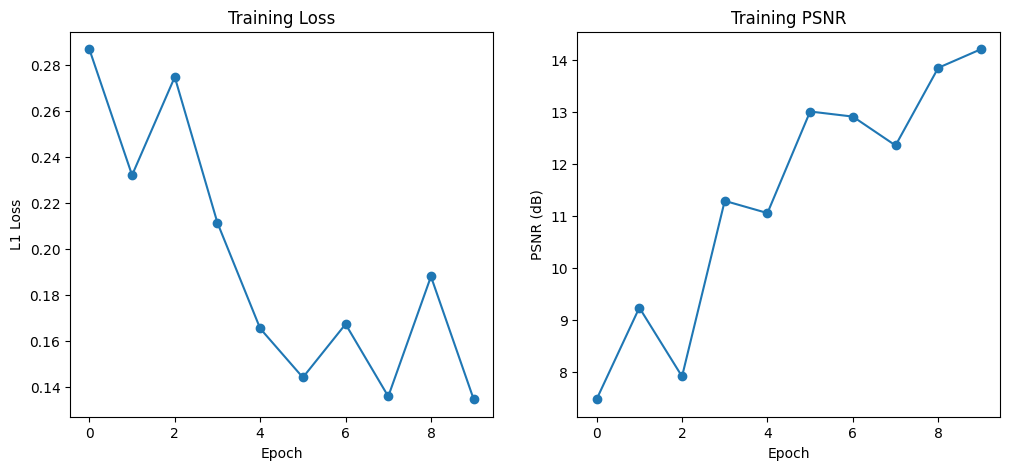

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")

# PSNR curve
plt.subplot(1,2,2)
plt.plot(train_psnr, marker='o')
plt.title("Training PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")

plt.show()

In [ ]:
# =============================
# EVALUATE TEST PERFORMANCE
# =============================

model.eval()

total_psnr = 0
total_ssim = 0
total_noisy_var = 0
total_denoised_var = 0
count = 0

with torch.no_grad():

    for noisy, clean in test_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        psnr = compute_psnr(output, clean)
        ssim_score = compute_ssim(output, clean)

        noisy_var = compute_variance(noisy)
        denoised_var = compute_variance(output)

        total_psnr += psnr
        total_ssim += ssim_score
        total_noisy_var += noisy_var
        total_denoised_var += denoised_var

        count += 1

avg_psnr = total_psnr / count
avg_ssim = total_ssim / count
avg_noisy_var = total_noisy_var / count
avg_denoised_var = total_denoised_var / count

print("Average Test PSNR:", avg_psnr, "dB")
print("Average Test SSIM:", avg_ssim)
print("Average Noisy Variance:", avg_noisy_var)
print("Average Denoised Variance:", avg_denoised_var)
print("Variance Reduction:", avg_noisy_var - avg_denoised_var)

In [ ]:
# =========================
# VISUALIZE RESULTS
# =========================

model.eval()
num_samples = 5
with torch.no_grad():
    for i, (noisy, clean) in enumerate(test_loader):
        if i >= num_samples:
            break
        noisy = noisy.to(device)
        clean = clean.to(device)

        output = model(noisy)

        # Convert tensors to numpy
        noisy_np = noisy.squeeze(0).permute(1,2,0).cpu().numpy()
        clean_np = clean.squeeze(0).permute(1,2,0).cpu().numpy()
        out_np = output.squeeze(0).permute(1,2,0).cpu().numpy()

        # Clip for display
        noisy_np = np.clip(noisy_np, 0, 1)
        clean_np = np.clip(clean_np, 0, 1)
        out_np = np.clip(out_np, 0, 1)

        import matplotlib.pyplot as plt

        plt.figure(figsize=(15,5))

        plt.subplot(1,3,1)
        plt.title("Low spp Noisy render")
        plt.imshow(noisy_np)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Model Output")
        plt.imshow(out_np)
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("High spp Reference")
        plt.imshow(clean_np)
        plt.axis("off")

        plt.show()

In [ ]:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# for i in range(100):
#     optimizer.zero_grad()
#     output = model(noisy)
#     loss = torch.nn.functional.l1_loss(output, clean)
#     loss.backward()
#     optimizer.step()

#     if i % 20 == 0:
#         print(i, loss.item())